# Corrige : Introduction aux reseaux de neurones
Un reseau de neurones est une fonction parametrique qui s'ecrit comme une succession d'operations lineaires et non-lineaires.
Par exemple, la fonction $f(x) = w \cdot \sigma(Wx + b)$ ou $x \in \mathbb{R}^n$ est l'entree, $w \in \mathbb{R}^h$, $W \in \mathbb{R}^{h \times n}$ et $b \in \mathbb{R}^h$ sont des parametres, $\sigma$ est une fonction non-lineaire et $\cdot$ est le produit scalaire.

Dans cet exemple $\sigma$ peut etre la fonction sigmoide $\sigma(x) = \frac{1}{1 + e^{-x}}$ ou bien la fonction $ReLU$ $\sigma(x) = \max(0, x)$.

In [2]:
import torch
import matplotlib.pyplot as plt

## Creation d'un reseau de neurones de R dans R avec ReLU
Prenons $n = 1$, $h = 10$, avec comme fonction non-lineaire $\sigma$ la fonction ReLU.
Initialiser un reseau de neurones $f(x)$ avec les parametres $w$, $W$ et $b$ prenant des valeurs aleatoires Gaussienne centree reduite.
Afficher le graphe de la fonction $f$ pour $x\in[-1, 1]$.

In [7]:
# Parametres
n = 1   # dimension d'entree
h = 10  # nombre de neurones caches

# Initialisation aleatoire des parametres
torch.manual_seed(42)  # pour reproductibilite, essayer avec une autre seed
w = torch.randn(h)      # vecteur de taille h
W = torch.randn(h, n)   # matrice h x n
b = torch.randn(h)      # vecteur de taille h

In [8]:
# Grille de points
x = torch.linspace(-1, 1, 100) # comme en numpy

# Calcul de f(x) = w . ReLU(Wx + b)
# x a shape (100,), on le reshape en (100, 1) pour le produit matriciel
x_reshape = x.view(-1, 1)  # shape (100, 1)

# z = Wx + b : on fait x @ W^T pour avoir (100, h)
z = x_reshape @ W.T + b  # shape (100, h)

# Activation ReLU
activation = torch.relu(z)  # shape (100, h)

# Produit scalaire avec w
f_relu = activation @ w  # shape (100,)

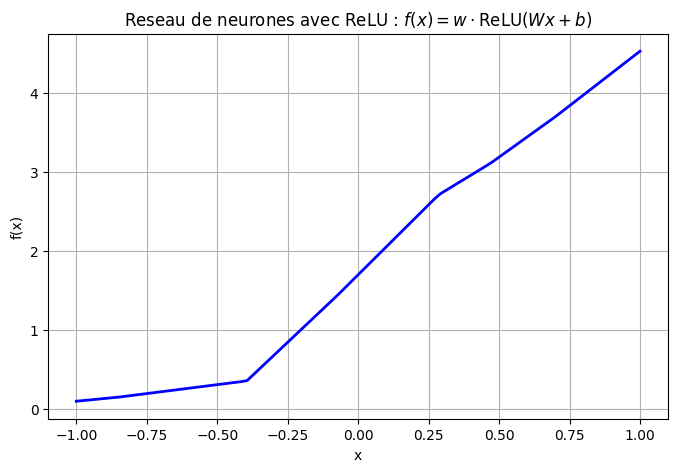

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(x.numpy(), f_relu.detach().numpy(), '-b', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'Reseau de neurones avec ReLU : $f(x) = w \cdot \mathrm{ReLU}(Wx + b)$')
plt.grid(True)
plt.show()

## Reseau de neurones avec activation Sigmoide
Meme chose avec la fonction sigmoide $\sigma(x) = \frac{1}{1 + e^{-x}}$.

In [10]:
# Activation sigmoide
activation_sigmoid = torch.sigmoid(z)  # shape (100, h)

# Produit scalaire avec w
f_sigmoid = activation_sigmoid @ w  # shape (100,)

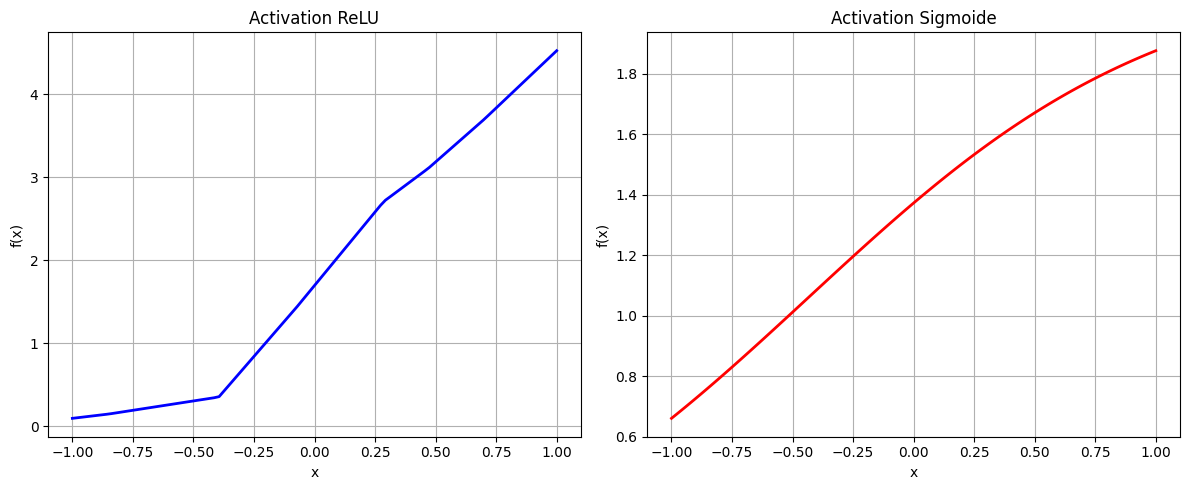

In [11]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(x.numpy(), f_relu.detach().numpy(), '-b', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Activation ReLU')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(x.numpy(), f_sigmoid.detach().numpy(), '-r', linewidth=2)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Activation Sigmoide')
plt.grid(True)

plt.tight_layout()
plt.show()

## Optimisation d'un reseau de neurones
On voudrait que cette fonction prenne la valeur 0 en 0, 1 en 0.5 et -2 en -0.5.

**Formulation mathematique :** On cherche les parametres $(w, W, b)$ qui minimisent l'erreur quadratique moyenne :
$$\mathcal{L}(w, W, b) = \frac{1}{3} \sum_{i=1}^{3} \left( f(x_i) - y_i \right)^2$$
avec $(x_1, y_1) = (0, 0)$, $(x_2, y_2) = (0.5, 1)$, $(x_3, y_3) = (-0.5, -2)$.

**Methode de resolution :** Descente de gradient. On calcule le gradient de $\mathcal{L}$ par rapport aux parametres grace a `backward()` de PyTorch, puis on met a jour les parametres dans la direction opposee au gradient.

In [17]:
# Donnees cibles
x_target = torch.tensor([0.0, 0.5, -0.5])
y_target = torch.tensor([0.0, 1.0, -2.0])

In [19]:
# Reinitialisation des parametres avec requires_grad=True
torch.manual_seed(123)
w = torch.randn(h, requires_grad=True)
W = torch.randn(h, n, requires_grad=True)
b = torch.randn(h, requires_grad=True)

In [20]:
def forward(x, w, W, b):
    """
    Calcule f(x) = w . ReLU(Wx + b)
    """
    if x.dim() == 1:
        x = x.view(-1, 1)
    z = x @ W.T + b
    a = torch.relu(z)
    return a @ w

def loss_fn(y_pred, y_target):
    """
    Erreur quadratique moyenne (MSE)
    """
    return torch.mean((y_pred - y_target) ** 2)

In [21]:
# Parametres d'optimisation
learning_rate = 0.1
n_iterations = 100

# Historique de la loss
loss_history = []

for i in range(n_iterations):
    # Forward pass
    y_pred = forward(x_target, w, W, b)
    
    # Calcul de la loss
    loss = loss_fn(y_pred, y_target)
    loss_history.append(loss.item())
    
    # Backward pass
    loss.backward()
    
    # Mise a jour des parametres
    with torch.no_grad():
        w -= learning_rate * w.grad
        W -= learning_rate * W.grad
        b -= learning_rate * b.grad
        
        # Remise a zero des gradients
        w.grad.zero_()
        W.grad.zero_()
        b.grad.zero_()
    
    if (i + 1) % 2 == 0:
        print(f"Iteration {i+1:4d} | Loss = {loss.item():.6f}")

Iteration    2 | Loss = 1.444810
Iteration    4 | Loss = 1.146020
Iteration    6 | Loss = 0.885185
Iteration    8 | Loss = 0.655653
Iteration   10 | Loss = 0.477595
Iteration   12 | Loss = 0.329079
Iteration   14 | Loss = 0.216802
Iteration   16 | Loss = 0.139056
Iteration   18 | Loss = 0.089474
Iteration   20 | Loss = 0.059826
Iteration   22 | Loss = 0.042646
Iteration   24 | Loss = 0.032577
Iteration   26 | Loss = 0.026332
Iteration   28 | Loss = 0.022102
Iteration   30 | Loss = 0.018958
Iteration   32 | Loss = 0.016443
Iteration   34 | Loss = 0.014332
Iteration   36 | Loss = 0.012513
Iteration   38 | Loss = 0.010924
Iteration   40 | Loss = 0.009529
Iteration   42 | Loss = 0.008302
Iteration   44 | Loss = 0.007223
Iteration   46 | Loss = 0.006276
Iteration   48 | Loss = 0.005446
Iteration   50 | Loss = 0.004719
Iteration   52 | Loss = 0.004084
Iteration   54 | Loss = 0.003530
Iteration   56 | Loss = 0.003048
Iteration   58 | Loss = 0.002641
Iteration   60 | Loss = 0.002279
Iteration 

In [22]:
# Verification des resultats
print("Resultats apres optimisation :")
print("-" * 35)
y_final = forward(x_target, w, W, b)
for xi, yi_target, yi_pred in zip(x_target, y_target, y_final):
    print(f"f({xi.item():5.2f}) = {yi_pred.item():7.4f}  (cible : {yi_target.item():5.2f})")

Resultats apres optimisation :
-----------------------------------
f( 0.00) = -0.0139  (cible :  0.00)
f( 0.50) =  1.0060  (cible :  1.00)
f(-0.50) = -1.9914  (cible : -2.00)


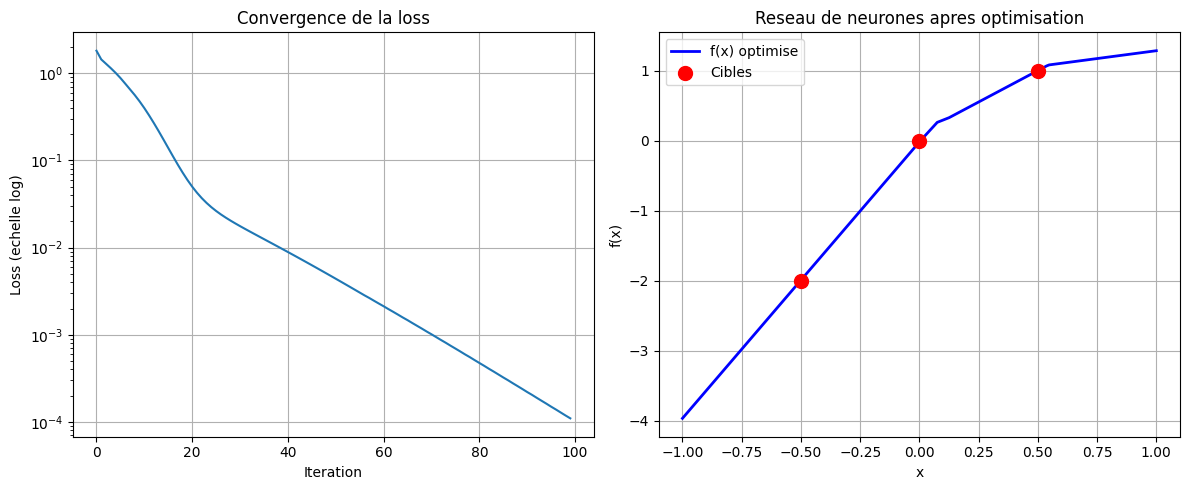

In [23]:
# Visualisation de la convergence
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.semilogy(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss (echelle log)')
plt.title('Convergence de la loss')
plt.grid(True)

# Fonction optimisee
plt.subplot(1, 2, 2)
x_plot = torch.linspace(-1, 1, 200)
with torch.no_grad():
    y_plot = forward(x_plot, w, W, b)

plt.plot(x_plot.numpy(), y_plot.numpy(), '-b', linewidth=2, label='f(x) optimise')
plt.scatter(x_target.numpy(), y_target.numpy(), c='red', s=100, zorder=5, label='Cibles')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Reseau de neurones apres optimisation')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Bonus : Utilisation de torch.optim
PyTorch fournit des optimiseurs plus sophistiques comme Adam, qui combine la descente de gradient avec un momentum adaptatif.

In [24]:
# Reinitialisation
torch.manual_seed(456)
w = torch.randn(h, requires_grad=True)
W = torch.randn(h, n, requires_grad=True)
b = torch.randn(h, requires_grad=True)

# Optimiseur Adam
optimizer = torch.optim.Adam([w, W, b], lr=0.1)

loss_history_adam = []

for i in range(500):
    optimizer.zero_grad()
    
    y_pred = forward(x_target, w, W, b)
    loss = loss_fn(y_pred, y_target)
    
    loss.backward()
    optimizer.step()
    
    loss_history_adam.append(loss.item())
    
    if (i + 1) % 100 == 0:
        print(f"Iteration {i+1:4d} | Loss = {loss.item():.6f}")

Iteration  100 | Loss = 0.012165
Iteration  200 | Loss = 0.000000
Iteration  300 | Loss = 0.000000
Iteration  400 | Loss = 0.000000
Iteration  500 | Loss = 0.000000


In [25]:
# Resultats avec Adam
print("Resultats avec Adam :")
print("-" * 35)
y_final = forward(x_target, w, W, b)
for xi, yi_target, yi_pred in zip(x_target, y_target, y_final):
    print(f"f({xi.item():5.2f}) = {yi_pred.item():7.4f}  (cible : {yi_target.item():5.2f})")

Resultats avec Adam :
-----------------------------------
f( 0.00) =  0.0000  (cible :  0.00)
f( 0.50) =  1.0000  (cible :  1.00)
f(-0.50) = -2.0000  (cible : -2.00)


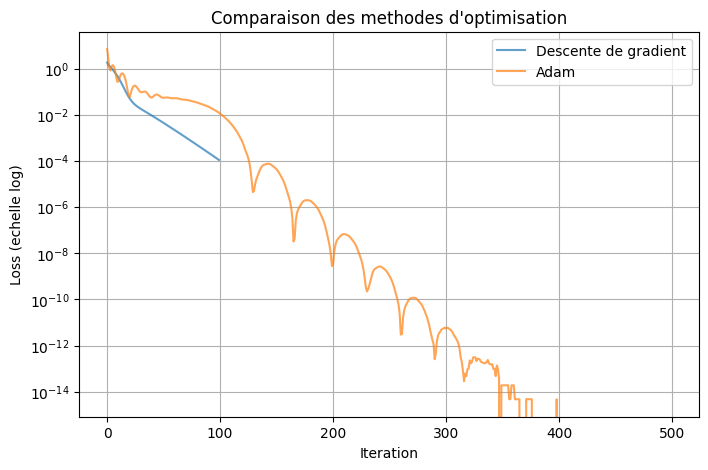

In [26]:
# Comparaison des methodes
plt.figure(figsize=(8, 5))
plt.semilogy(loss_history[:500], label='Descente de gradient', alpha=0.7)
plt.semilogy(loss_history_adam, label='Adam', alpha=0.7)
plt.xlabel('Iteration')
plt.ylabel('Loss (echelle log)')
plt.title('Comparaison des methodes d\'optimisation')
plt.legend()
plt.grid(True)
plt.show()